In [46]:
import sys
from pathlib import Path
import shutil

# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

# Force reload of modules
for module in list(sys.modules.keys()):
    if 'src' in module:
        del sys.modules[module]

# IMPORTANT: Clear old processed/raw folders to regenerate with 500+ images per class
PROCESSED_OLD = project_root / 'data' / 'processed' / 'isic'
RAW_ISIC_OLD = project_root / 'data' / 'raw' / 'isic'

if PROCESSED_OLD.exists():
    shutil.rmtree(PROCESSED_OLD)
    print(f"Cleaned: {PROCESSED_OLD}")
if RAW_ISIC_OLD.exists():
    shutil.rmtree(RAW_ISIC_OLD)
    print(f"Cleaned: {RAW_ISIC_OLD}")

print(f"Added to path: {project_root}")
print("Ready to process with 500+ images per class")

Cleaned: d:\git projects\certified-attribution-medical-imaging\data\processed\isic
Cleaned: d:\git projects\certified-attribution-medical-imaging\data\raw\isic
Added to path: d:\git projects\certified-attribution-medical-imaging
Ready to process with 500+ images per class


In [16]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

print("Env set")


Env set


In [49]:
# Dependencies
import os
from pathlib import Path
import json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import shutil, random, csv
print('Imports ready')

Imports ready


In [47]:
# ISIC-2019 Data Processing with 500+ images per class
print("=" * 70)
print("ISIC-2019 DATA PROCESSING (500+ images per class)")
print("=" * 70)

# Setup paths
PROJECT_ROOT = Path.cwd().parent.parent
KAGGLE_DATASET = 'salviohexia/isic-2019-skin-lesion-images-for-classification'
DOWNLOAD_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'isic_kaggle'
PROCESSED = PROJECT_ROOT / 'data' / 'processed' / 'isic'
RAW_ISIC = PROJECT_ROOT / 'data' / 'raw' / 'isic'
SPLIT_RATIOS = (0.7, 0.15, 0.15)
SEED = 42
MIN_IMAGES_PER_CLASS = 500  # NEW: Keep at least 500 images per class

random.seed(SEED)
PROCESSED.mkdir(parents=True, exist_ok=True)
RAW_ISIC.mkdir(parents=True, exist_ok=True)

# Check if downloaded
if not DOWNLOAD_ROOT.exists() or not list(DOWNLOAD_ROOT.rglob('ISIC_2019_Training_GroundTruth*.csv')):
    raise FileNotFoundError(f"Dataset not found at {DOWNLOAD_ROOT}. Download manually first.")

print(f"\n✓ Using downloaded data: {DOWNLOAD_ROOT}")

# Parse ground truth
def _parse_gt(csv_path):
    mapping = {}
    with open(csv_path, 'r', newline='') as fh:
        reader = csv.DictReader(fh)
        for row in reader:
            image = row.get('image') or row.get('image_name') or row.get('image_id')
            if image is None:
                continue
            label = None
            for col in ['MEL','NV','BCC','AK','BKL','DF','VASC','SCC','UNK']:
                val = row.get(col)
                if val is None:
                    continue
                try:
                    if int(float(val)) == 1:
                        label = col
                        break
                except Exception:
                    continue
            if label is None:
                label = 'UNK'
            mapping[image] = label
    return mapping

gt = list(DOWNLOAD_ROOT.rglob('ISIC_2019_Training_GroundTruth*.csv'))[0]
print(f"✓ Found ground-truth CSV: {gt.name}")
mapping = _parse_gt(gt)
print(f"✓ Parsed labels for {len(mapping)} images")

# Collect images
image_files = {p.name: p for p in DOWNLOAD_ROOT.rglob('*') if p.suffix.lower() in ['.jpg','.jpeg','.png','.tif']}
print(f"✓ Found {len(image_files)} image files")

# Build class buckets
class_buckets = {}
for img_name, label in mapping.items():
    p = image_files.get(img_name)
    if p is None:
        for ext in ['.jpg','.jpeg','.png']:
            alt = img_name + ext
            if alt in image_files:
                p = image_files[alt]
                break
    if p is None:
        continue
    class_buckets.setdefault(label, []).append(p)

counts_before = {k: len(v) for k, v in class_buckets.items()}
print(f"\n✓ Class distribution BEFORE balancing:")
for cls, count in sorted(counts_before.items()):
    print(f"  {cls}: {count}")

# NEW: Balance to 500+ per class (or minimum available)
nonzero = [len(v) for v in class_buckets.values() if len(v) > 0]
min_class_size = min(nonzero)
target = max(MIN_IMAGES_PER_CLASS, min_class_size)
print(f"\n✓ Balancing strategy: Keep {target} per class (min available: {min_class_size})")

# Create processed layout
for split in ['train','val','test']:
    (PROCESSED / split).mkdir(parents=True, exist_ok=True)

# Sample, split and copy
for label, files in class_buckets.items():
    if len(files) == 0:
        continue
    random.shuffle(files)
    sampled = files[:target] if len(files) >= target else files.copy()
    n = len(sampled)
    r1 = int(n * SPLIT_RATIOS[0])
    r2 = r1 + int(n * SPLIT_RATIOS[1])
    splits = {'train': sampled[:r1], 'val': sampled[r1:r2], 'test': sampled[r2:]}
    for sname, items in splits.items():
        class_dir = PROCESSED / sname / label
        class_dir.mkdir(parents=True, exist_ok=True)
        for src in items:
            dst = class_dir / src.name
            if not dst.exists():
                shutil.copyfile(src, dst)

# Write processed CSVs
for sname in ['train','val','test']:
    rows = []
    for label in sorted(class_buckets.keys()):
        dirp = PROCESSED / sname / label
        if not dirp.exists():
            continue
        for p in sorted(dirp.iterdir()):
            rows.append({'image': str(p.relative_to(PROCESSED)), 'label': label})
    csv_path = PROCESSED / f'{sname}_labels.csv'
    with open(csv_path, 'w', newline='') as fh:
        writer = csv.DictWriter(fh, fieldnames=['image','label'])
        writer.writeheader()
        for r in rows:
            writer.writerow(r)
    print(f"✓ Wrote {csv_path.name}: {len(rows)} rows")

# Convert to RAW_ISIC layout (for ISICDataset)
print(f"\n✓ Converting to ISICDataset format...")
class_to_idx = {'AK': 0, 'BCC': 1, 'BKL': 2, 'DF': 3, 'MEL': 4, 'NV': 5, 'SCC': 6, 'VASC': 7}

for split in ['train','val','test']:
    split_dir = RAW_ISIC / split
    images_dir = split_dir / 'images'
    split_dir.mkdir(parents=True, exist_ok=True)
    images_dir.mkdir(parents=True, exist_ok=True)
    csv_path = PROCESSED / f'{split}_labels.csv'
    labels_json = {}
    if not csv_path.exists():
        continue
    with open(csv_path, 'r') as fh:
        reader = csv.DictReader(fh)
        for row in reader:
            rel = Path(row['image'])
            src = PROCESSED / rel
            if not src.exists():
                continue
            dst = images_dir / src.name
            if not dst.exists():
                shutil.copyfile(src, dst)
            cls = row['label']
            labels_json[src.name] = class_to_idx.get(cls, -1)
    with open(split_dir / 'labels.json', 'w') as fh:
        json.dump(labels_json, fh)
    print(f"✓ {split}: {len(labels_json)} items with 8-class labels")

print("\n" + "=" * 70)
print("✓ PROCESSING COMPLETE - Data ready for ISICDataset!")
print("=" * 70)

ISIC-2019 DATA PROCESSING (500+ images per class)

✓ Using downloaded data: d:\git projects\certified-attribution-medical-imaging\data\raw\isic_kaggle
✓ Found ground-truth CSV: ISIC_2019_Training_GroundTruth.csv
✓ Parsed labels for 25331 images
✓ Found 25331 image files

✓ Class distribution BEFORE balancing:
  AK: 867
  BCC: 3323
  BKL: 2624
  DF: 239
  MEL: 4522
  NV: 12875
  SCC: 628
  VASC: 253

✓ Balancing strategy: Keep 500 per class (min available: 239)
✓ Wrote train_labels.csv: 2444 rows
✓ Wrote val_labels.csv: 522 rows
✓ Wrote test_labels.csv: 526 rows

✓ Converting to ISICDataset format...
✓ train: 2444 items with 8-class labels
✓ val: 522 items with 8-class labels
✓ test: 526 items with 8-class labels

✓ PROCESSING COMPLETE - Data ready for ISICDataset!


## Data Setup

**Data Location**: All data is stored at **project root**: `d:\git projects\certified-attribution-medical-imaging\data\`

**Folder Structure**:

```
data/
├── raw/
│   ├── isic_kaggle/          # Downloaded raw Kaggle data
│   └── isic/                 # Processed for ISICDataset (train/val/test with labels.json)
└── processed/
    └── isic/                 # Balanced intermediate format (train/val/test with class folders)
```

### To Use Existing Downloaded Data

If you've already downloaded the ISIC-2019 dataset, place it at: `data/raw/isic_kaggle/`

The script will:

1. **Check** if data exists (skip download if present)
2. **Process** into class folders in `data/processed/isic/`
3. **Convert** to ISICDataset format in `data/raw/isic/` with 8-class `labels.json`

Run cell 4 (Data Preparation) to start processing.

## Verification: load processed data with `ISICDataset`

Run the cell below to instantiate `ISICDataset` and a `DataLoader` to confirm the processed files load correctly.


In [48]:
# Check data status and folder structure
print("=" * 60)
print("DATA STATUS CHECK")
print("=" * 60)

PROJECT_ROOT = Path.cwd().parent.parent
DOWNLOAD_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'isic_kaggle'
PROCESSED = PROJECT_ROOT / 'data' / 'processed' / 'isic'
RAW_ISIC = PROJECT_ROOT / 'data' / 'raw' / 'isic'

print(f"\nProject root: {PROJECT_ROOT}")

# Check downloaded data
print(f"\n1. Downloaded data ({DOWNLOAD_ROOT.name}):")
if DOWNLOAD_ROOT.exists():
    gt_file = list(DOWNLOAD_ROOT.rglob('ISIC_2019_Training_GroundTruth*.csv'))
    if gt_file:
        print(f"   ✓ Ground truth CSV found")
    images = list(DOWNLOAD_ROOT.rglob('*.jpg')) + list(DOWNLOAD_ROOT.rglob('*.jpeg'))
    print(f"   ✓ {len(images)} images found")
else:
    print(f"   ✗ Not found - download data to {DOWNLOAD_ROOT}")

# Check processed data
print(f"\n2. Processed data ({PROCESSED.name}):")
if PROCESSED.exists():
    for split in ['train', 'val', 'test']:
        split_dir = PROCESSED / split
        if split_dir.exists():
            classes = [d.name for d in split_dir.iterdir() if d.is_dir()]
            total_images = sum(len(list((split_dir / c).glob('*.jpg'))) for c in classes)
            print(f"   ✓ {split}: {len(classes)} classes, {total_images} images")
else:
    print(f"   ✗ Not found - run cell 4 to process data")

# Check ISICDataset format
print(f"\n3. ISICDataset format ({RAW_ISIC.name}):")
if RAW_ISIC.exists():
    for split in ['train', 'val', 'test']:
        split_dir = RAW_ISIC / split
        labels_file = split_dir / 'labels.json'
        if labels_file.exists():
            with open(labels_file) as f:
                labels = json.load(f)
                label_values = set(labels.values())
            print(f"   ✓ {split}: {len(labels)} items, labels {sorted(label_values)}")
else:
    print(f"   ✗ Not found - run cell 4 to convert processed data")

print("\n" + "=" * 60)

DATA STATUS CHECK

Project root: d:\git projects\certified-attribution-medical-imaging

1. Downloaded data (isic_kaggle):
   ✓ Ground truth CSV found
   ✓ 25331 images found

2. Processed data (isic):
   ✓ train: 8 classes, 2444 images
   ✓ val: 8 classes, 522 images
   ✓ test: 8 classes, 526 images

3. ISICDataset format (isic):
   ✓ train: 2444 items, labels [0, 1, 2, 3, 4, 5, 6, 7]
   ✓ val: 522 items, labels [0, 1, 2, 3, 4, 5, 6, 7]
   ✓ test: 526 items, labels [0, 1, 2, 3, 4, 5, 6, 7]



In [52]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
val_transform = T.Compose([
    T.Resize((256,256)),
    T.CenterCrop(224),
    T.Lambda(lambda img: img.convert('RGB') if img.mode!='RGB' else img),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Class mapping for 8-class classification
CLASS_NAMES = ['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']
CLASS_IDX_TO_NAME = {i: name for i, name in enumerate(CLASS_NAMES)}

from src.datasets.isic import ISICDataset
train_ds = ISICDataset(root_dir=str(RAW_ISIC), split='train', transform=val_transform)
print('Train samples:', len(train_ds))
print('Number of classes:', len(CLASS_NAMES))
print('Classes:', CLASS_NAMES)

# Get a batch with mixed classes
dl = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
batch = next(iter(dl))
    
if batch is not None:
    imgs = batch['image']
    labels = batch['label']
    print('\nBatch images shape:', imgs.shape)
    print('Batch labels:', labels.tolist())
    print('Batch class names:', [CLASS_IDX_TO_NAME[l] for l in labels.tolist()])
else:
    print('No samples found in train split')

Train samples: 2444
Number of classes: 8
Classes: ['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']

Batch images shape: torch.Size([8, 3, 224, 224])
Batch labels: [6, 1, 7, 6, 4, 3, 0, 6]
Batch class names: ['SCC', 'BCC', 'VASC', 'SCC', 'MEL', 'DF', 'AK', 'SCC']


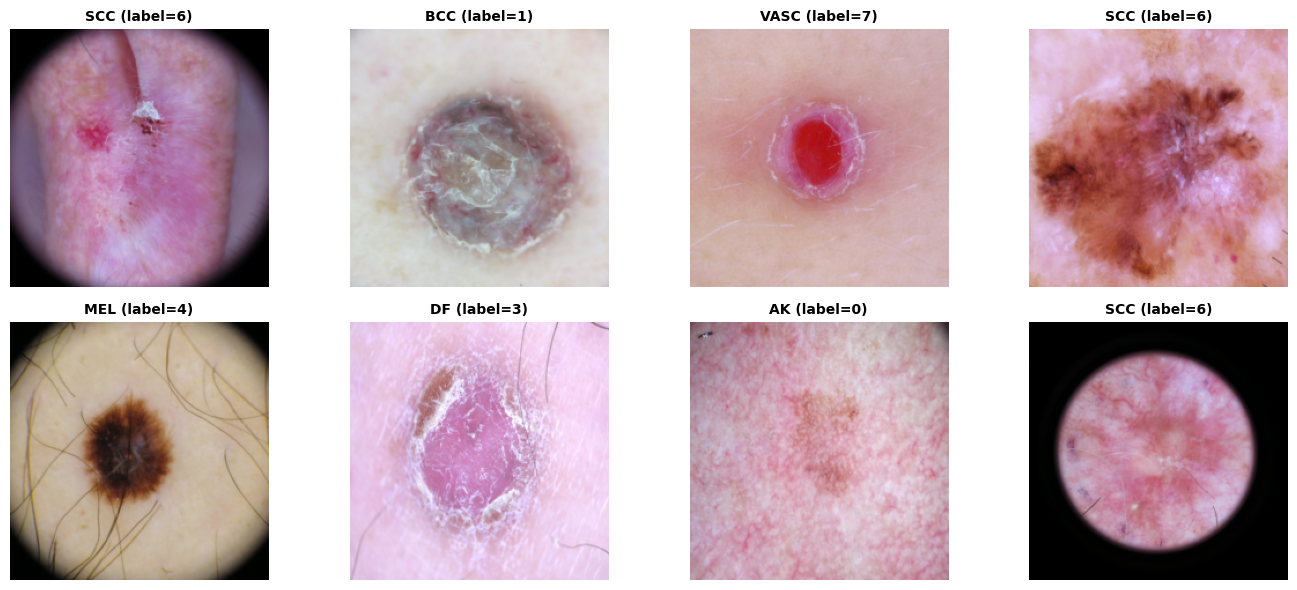

In [53]:
# Visualize a few samples from different classes
if 'batch' in globals() and batch is not None:
    imgs = batch['image']
    labels = batch['label']
    inv_norm = T.Normalize(mean=[-m/s for m,s in zip(IMAGENET_MEAN, IMAGENET_STD)], std=[1/s for s in IMAGENET_STD])
    fig, axs = plt.subplots(2,4, figsize=(14,6))
    for i, ax in enumerate(axs.flatten()):
        if i>=imgs.size(0): break
        img = inv_norm(imgs[i]).permute(1,2,0).numpy()
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        label = labels[i].item()
        class_name = CLASS_IDX_TO_NAME.get(label, 'Unknown')
        ax.set_title(f'{class_name} (label={label})', fontsize=10, fontweight='bold')
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('No batch to visualize')